<a href="https://colab.research.google.com/github/imak2363/CVD-Classification-in-Bangladesh/blob/main/CVD_Full_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup

In [3]:
import sys
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

RS = 42
np.random.seed(RS)

In [21]:
!pip install scikeras

In [4]:
import struct
from google.colab import files

def read_sav(path):
    with open(path, "rb") as f:
        raw = f.read()
    pos = 0
    def unpack(fmt, data, offset):
        size = struct.calcsize(fmt)
        return struct.unpack_from(fmt, data, offset), offset + size

    rec_type = raw[pos:pos+4]; pos += 4
    assert rec_type == b"$FL2"
    pos += 60
    (layout_code,), pos = unpack("<i", raw, pos)
    (nominal_case_size,), pos = unpack("<i", raw, pos)
    (compressed,), pos = unpack("<i", raw, pos)
    (weight_index,), pos = unpack("<i", raw, pos)
    (ncases,), pos = unpack("<i", raw, pos)
    (bias,), pos = unpack("<d", raw, pos)
    pos += 9 + 8 + 64 + 3

    var_labels_map = {}
    value_labels_by_var_index = {}
    pending_value_label_specs = []
    var_record_order = []
    long_name_map = {}

    while True:
        (rtype,), pos = unpack("<i", raw, pos)
        if rtype == 2:
            (var_type,), pos = unpack("<i", raw, pos)
            (has_label,), pos = unpack("<i", raw, pos)
            (n_missing,), pos = unpack("<i", raw, pos)
            pos += 8
            name_raw = raw[pos:pos+8]; pos += 8
            name = name_raw.decode("latin1").strip()
            if var_type == 0:
                var_record_order.append((name, 0))
            elif var_type > 0:
                var_record_order.append((name, var_type))
            else:
                var_record_order.append((None, -1))
            if has_label:
                (label_len,), pos = unpack("<i", raw, pos)
                pad = (4 - label_len % 4) % 4
                pos += label_len + pad
            if n_missing != 0:
                pos += abs(n_missing) * 8
        elif rtype in (3, 4):
            (n_labels,), pos = unpack("<i", raw, pos)
            values = {}
            for _ in range(n_labels):
                (val,), pos = unpack("<d", raw, pos)
                (label_len,), pos = unpack("<B", raw, pos)
                pad = (8 - (label_len + 1) % 8) % 8
                pos += label_len + pad
            (rtype4,), pos = unpack("<i", raw, pos)
            (n_vars,), pos = unpack("<i", raw, pos)
            var_indices, pos = unpack(f"<{n_vars}i", raw, pos)
        elif rtype == 6:
            (n_lines,), pos = unpack("<i", raw, pos)
            pos += n_lines * 80
        elif rtype == 7:
            (subtype,), pos = unpack("<i", raw, pos)
            (size,), pos = unpack("<i", raw, pos)
            (count,), pos = unpack("<i", raw, pos)
            payload = raw[pos:pos + size * count]; pos += size * count
            if subtype == 13:
                text = payload.decode("latin1", errors="replace")
                for pair in text.split("\t"):
                    if "=" in pair:
                        short, long_ = pair.split("=", 1)
                        long_name_map[short.strip().upper()] = long_.strip()
        elif rtype == 999:
            (_,), pos = unpack("<i", raw, pos)
            break
        else:
            raise ValueError(f"Unknown record type {rtype} at {pos}")

    final_vars = []
    i = 0
    while i < len(var_record_order):
        name, vt = var_record_order[i]
        if vt == -1:
            i += 1; continue
        if vt == 0:
            final_vars.append((name, False, 0)); i += 1
        else:
            j = i + 1
            while j < len(var_record_order) and var_record_order[j][1] == -1:
                j += 1
            final_vars.append((name, True, vt)); i = j

    seg_to_name = []
    for name, vt in var_record_order:
        seg_to_name.append(seg_to_name[-1] if vt == -1 and seg_to_name else name)

    def decompress(raw, pos, bias):
        n = len(raw)
        while pos < n:
            codes = raw[pos:pos+8]; pos += 8
            if len(codes) < 8: break
            for code_ in codes:
                if code_ == 0: continue
                elif code_ == 252: return
                elif code_ == 253:
                    chunk = raw[pos:pos+8]; pos += 8
                    yield ("raw", chunk)
                elif code_ == 254:
                    yield ("raw", b" " * 8)
                elif code_ == 255:
                    yield ("sysmiss", None)
                else:
                    yield ("num", float(code_ - bias))

    ncols_seg = len(var_record_order)
    data_rows = []
    if compressed:
        gen = decompress(raw, pos, bias)
        current_row = []; seg_i = 0
        for kind, val in gen:
            vn = seg_to_name[seg_i] if seg_i < len(seg_to_name) else None
            current_row.append((kind, val, vn)); seg_i += 1
            if seg_i == ncols_seg:
                data_rows.append(current_row); current_row = []; seg_i = 0
    else:
        rec_bytes = ncols_seg * 8
        while pos + rec_bytes <= len(raw):
            row = []
            for k in range(ncols_seg):
                chunk = raw[pos:pos+8]; pos += 8
                vn = seg_to_name[k] if k < len(seg_to_name) else None
                row.append(("rawnum", chunk, vn))
            data_rows.append(row)

    columns = {name: [] for name, _, _ in final_vars}
    var_is_str = {name: is_str for name, is_str, _ in final_vars}
    for row in data_rows:
        acc = {}
        for item in row:
            kind, val, vn = (item[0].replace("rawnum", "raw"), item[1], item[2])
            if vn is None: continue
            if var_is_str.get(vn, False):
                if kind == "raw":
                    acc[vn] = acc.get(vn, b"") + val
            else:
                if kind == "num": acc[vn] = val
                elif kind == "sysmiss": acc[vn] = np.nan
                elif kind == "raw": acc[vn] = struct.unpack("<d", val)[0]
        for name, is_str, width in final_vars:
            v = acc.get(name, np.nan if not is_str else b"")
            if is_str and isinstance(v, (bytes, bytearray)):
                v = v.decode("latin1", errors="replace").rstrip()
            columns[name].append(v)

    df = pd.DataFrame({name: columns[name] for name, _, _ in final_vars})
    if long_name_map:
        rename = {name: long_name_map[name.upper()] for name, _, _ in final_vars if name.upper() in long_name_map}
        df = df.rename(columns=rename)
    return df

# --- Upload file and read into DataFrame ---
print("Please upload the .sav file.")
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    # Save the uploaded content to a temporary file
    with open(uploaded_filename, "wb") as f:
        f.write(uploaded[uploaded_filename])
    df = read_sav(uploaded_filename)
    print("Shape:", df.shape)
    display(df.head())
else:
    print("No file was uploaded.")

Please upload the .sav file.


Saving heart (1).sav to heart (1) (2).sav
Shape: (1222, 28)


,Heart_Disease,Age,Gender,Education,Eco_Cond,Physical_Exercise,Sound_Sleep,Junk_Food,Salt,Feel_Bad,Feel_zeroInt,Feel_Hopeless,Smoke,Drink_Alcohol,Colestrol,BP,Heartdisease_family,Animia,Diabeties,Hypertension,Sleepapnea,IrregularHeartRhythms,CoronaryDisease,Angina,KidneyLungsDisease,Take_ColestrolMedication,BMI,BMI_Grouped
0,1.0,51.0,1.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,28.823029,2.0
1,0.0,51.0,0.0,3.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.718371,0.0
2,1.0,59.0,1.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,18.221455,0.0
3,1.0,45.0,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,18.709460,1.0
4,1.0,60.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,15.300765,0.0


## 1. Final feature set and cohort definitions

The 19 predictors used in the final model, selected by univariate screening
(chi-square/t-test ranking) combined with clinical judgement about modifiable
risk factors (see Methods, Section 2.7).

In [5]:
FINAL_19 = ['Colestrol', 'Hypertension', 'IrregularHeartRhythms', 'Sleepapnea',
            'Take_ColestrolMedication', 'Feel_Bad', 'Animia', 'Angina', 'Age',
            'Salt', 'CoronaryDisease', 'Heartdisease_family', 'Diabeties',
            'Junk_Food', 'BP', 'Smoke', 'Feel_Hopeless', 'Feel_zeroInt', 'BMI']

CATEGORICAL = ['Gender', 'Education', 'Eco_Cond', 'Physical_Exercise', 'Sound_Sleep',
               'Junk_Food', 'Salt', 'Feel_Bad', 'Feel_zeroInt', 'Feel_Hopeless', 'Smoke',
               'Drink_Alcohol', 'Heartdisease_family', 'Animia', 'Diabeties', 'Hypertension',
               'Sleepapnea', 'IrregularHeartRhythms', 'CoronaryDisease', 'Angina',
               'KidneyLungsDisease', 'Take_ColestrolMedication', 'BMI_Grouped',
               'Colestrol', 'BP']
CONTINUOUS = ['Age', 'BMI']

y = df['Heart_Disease'].astype(int)
print(f"Total N = {len(df)}: {sum(y==1)} with CVD ({sum(y==1)/len(y)*100:.1f}%), "
      f"{sum(y==0)} without ({sum(y==0)/len(y)*100:.1f}%)")

# Primary cohort = rows 651-1221 (collected 2024); secondary/pooled = rows 0-650 (Hossain et al., 2023)
primary_idx = df.index[651:]
print(f"Secondary cohort (rows 0-650): n={651}, CVD prevalence = {(y[:651]==1).mean()*100:.1f}%")
print(f"Primary cohort (rows 651-1221): n={len(primary_idx)}, CVD prevalence = {(y[651:]==1).mean()*100:.1f}%")

Total N = 1222: 806 with CVD (66.0%), 416 without (34.0%)
Secondary cohort (rows 0-650): n=651, CVD prevalence = 60.1%
Primary cohort (rows 651-1221): n=571, CVD prevalence = 72.7%


## 2. Table 1 — Participant characteristics by cardiovascular disease status

For each binary/categorical variable, values are the percentage with CVD among
those with the risk factor present vs. absent (row percentages), tested by
chi-square; continuous variables are mean (SD), tested by Welch's t-test.

In [6]:
from scipy import stats

all_vars = [c for c in df.columns if c != 'Heart_Disease']
rows = []
for var in all_vars:
    if var in CONTINUOUS:
        g1 = df.loc[y == 1, var]; g0 = df.loc[y == 0, var]
        t, p = stats.ttest_ind(g1, g0, equal_var=False)
        rows.append({'Variable': var, 'Type': 'continuous',
                     'CVD_present': f"{g1.mean():.1f} ({g1.std():.1f})",
                     'CVD_absent': f"{g0.mean():.1f} ({g0.std():.1f})",
                     'Test': 't-test', 'p_value': p})
    else:
        levels = sorted(df[var].dropna().unique())
        ct = pd.crosstab(df[var], y)
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        if len(levels) == 2:
            hi = levels[1]
            sub1 = df[df[var] == hi]; sub0 = df[df[var] == levels[0]]
            pct1 = (sub1['Heart_Disease'] == 1).mean() * 100
            pct0 = (sub0['Heart_Disease'] == 1).mean() * 100
            rows.append({'Variable': var, 'Type': 'categorical (binary)',
                         'CVD_present': f"{pct1:.1f}% (n={len(sub1)})",
                         'CVD_absent': f"{pct0:.1f}% (n={len(sub0)})",
                         'Test': 'chi-square', 'p_value': p})
        else:
            rows.append({'Variable': var, 'Type': f'categorical ({len(levels)} levels)',
                         'CVD_present': 'see multi-level breakdown', 'CVD_absent': '',
                         'Test': 'chi-square', 'p_value': p})

table1 = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
table1.to_csv('Table1.csv', index=False)
print("Significant at p<0.05:", (table1['p_value'] < 0.05).sum(), "of", len(table1))
print("Not significant:", table1.loc[table1['p_value'] >= 0.05, 'Variable'].tolist())
table1

Significant at p<0.05: 26 of 27
Not significant: ['Drink_Alcohol']


,Variable,Type,CVD_present,CVD_absent,Test,p_value
0,Colestrol,categorical (binary),90.9% (n=833),12.6% (n=389),chi-square,1.220525e-158
1,Feel_Bad,categorical (binary),87.3% (n=902),5.9% (n=320),chi-square,1.709282e-152
2,Sleepapnea,categorical (binary),90.9% (n=812),16.6% (n=410),chi-square,5.643095e-147
3,IrregularHeartRhythms,categorical (binary),96.5% (n=657),30.4% (n=565),chi-square,9.275207e-130
4,Hypertension,categorical (binary),94.2% (n=688),29.6% (n=534),chi-square,6.658453e-123
5,Feel_Hopeless,categorical (binary),82.6% (n=948),8.4% (n=274),chi-square,1.201102e-114
6,Angina,categorical (binary),93.2% (n=674),32.5% (n=548),chi-square,2.914744e-109
7,BP,categorical (binary),92.7% (n=669),33.6% (n=553),chi-square,1.192886e-103
8,Diabeties,categorical (binary),87.1% (n=745),32.9% (n=477),chi-square,3.296300e-84
9,Heartdisease_family,categorical (binary),87.4% (n=672),39.8% (n=550),chi-square,1.075657e-67


### Feature-selection check: univariate p-value ranking vs. the final 19 features

This confirms the corrected Methods description (Section 2.7): the 19 final
features overlap 16/19 with the top-19 ranked purely by univariate p-value: three
features with weaker univariate signal (Salt, Junk_Food, BMI) were kept ahead of
three stronger ones (Sound_Sleep, Education, KidneyLungsDisease) on clinical
grounds, as modifiable risk factors.

In [7]:
top19_by_p = set(table1.sort_values('p_value').head(19)['Variable'])
final19_set = set(FINAL_19)
print("Overlap:", len(top19_by_p & final19_set), "/ 19")
print("In final 19 but not top-19-by-p:", sorted(final19_set - top19_by_p))
print("In top-19-by-p but not final 19:", sorted(top19_by_p - final19_set))

Overlap: 16 / 19
In final 19 but not top-19-by-p: ['BMI', 'Junk_Food', 'Salt']
In top-19-by-p but not final 19: ['Education', 'KidneyLungsDisease', 'Sound_Sleep']


## 3. Preprocessing pipeline

Missing-value imputation was performed upstream (this analytic file, prepared in
SPSS, has no remaining missing values). The pipeline below matches Methods,
Section 2.7 exactly: an 80/20 stratified split, SMOTE fit on the training
partition only (computed across all 27 collected covariates, not just the final
19, matching the original notebook's cell order), selection of the final 19
features, then StandardScaler fit on the training partition alone.

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Missing values remaining:", df.isna().sum().sum())

X_full = df.drop(columns=['Heart_Disease']).astype(float)
y_arr = y.values
cols = list(X_full.columns)

Xtr_full, Xte_full, ytr, yte = train_test_split(X_full.values, y_arr, test_size=0.2,
                                                 random_state=RS, stratify=y_arr)
sm = SMOTE(random_state=RS)
Xtr_sm_full, ytr_sm = sm.fit_resample(Xtr_full, ytr)

train_df = pd.DataFrame(Xtr_sm_full, columns=cols)
test_df = pd.DataFrame(Xte_full, columns=cols)
Xtr_sel = train_df[FINAL_19].values
Xte_sel = test_df[FINAL_19].values

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_sel)
Xte_s = scaler.transform(Xte_sel)

print(f"n_train_raw={len(ytr)} (CVD={sum(ytr==1)}, non-CVD={sum(ytr==0)})")
print(f"n_train_after_SMOTE={len(ytr_sm)} (CVD={sum(ytr_sm==1)}, non-CVD={sum(ytr_sm==0)})")
print(f"n_test={len(yte)} (CVD={sum(yte==1)}, non-CVD={sum(yte==0)})")

Missing values remaining: 0
n_train_raw=977 (CVD=644, non-CVD=333)
n_train_after_SMOTE=1288 (CVD=644, non-CVD=644)
n_test=245 (CVD=162, non-CVD=83)


## 4. Multicollinearity check — Supporting Information Table S2 (Variance Inflation Factor)

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = df[FINAL_19].astype(float)
X_vif_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i + 1) for i in range(len(X_vif.columns))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data.to_csv('Table_S2_VIF.csv', index=False)
print("Max VIF:", round(vif_data['VIF'].max(), 2), "(no evidence of problematic multicollinearity)")
vif_data

Max VIF: 3.24 (no evidence of problematic multicollinearity)


,Variable,VIF
0,Feel_Bad,3.242497
1,Colestrol,3.064226
2,Sleepapnea,2.838658
3,IrregularHeartRhythms,2.450072
4,Feel_Hopeless,2.299630
5,Hypertension,2.173643
6,Diabeties,2.028628
7,Angina,2.010988
8,BP,1.947148
9,Take_ColestrolMedication,1.735056


## 5. Model development — six classifiers, one cell each

**Comparators** (SVM, Decision Tree, Random Forest, MLP, DNN) use default
scikit-learn/Keras hyperparameters with `random_state=42`. The original notebook
tuned these via GridSearchCV/RandomizedSearchCV (Supporting Information Table
S4); those exact tuned values are not reproduced here (see caveat at the top of
this notebook).

**The proposed stacking ensemble** uses the exact seeded architecture reported
in Methods, Section 2.8, and its results below match the published manuscript.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, recall_score,
                              f1_score, roc_auc_score, brier_score_loss)
import tensorflow as tf
from tensorflow.keras import layers, models as kmodels
from scikeras.wrappers import KerasClassifier # Import KerasClassifier

def bootstrap_ci(correct, n_boot=10000, seed=RS, alpha=0.05):
    rng = np.random.RandomState(seed)
    n = len(correct); arr = np.asarray(correct)
    boots = np.array([arr[rng.randint(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return lo, hi

results, probas, preds = {}, {}, {}

def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    lo, hi = bootstrap_ci((y_pred == y_true).astype(int))
    results[name] = dict(accuracy=acc, ci_lo=lo, ci_hi=hi, sensitivity=recall_score(y_true, y_pred),
                          specificity=tn/(tn+fp), precision=precision_score(y_true, y_pred),
                          f1=f1_score(y_true, y_pred), auc=roc_auc_score(y_true, y_proba),
                          brier=brier_score_loss(y_true, y_proba), tn=tn, fp=fp, fn=fn, tp=tp)
    probas[name] = y_proba; preds[name] = y_pred
    print(f"{name:20s} acc={acc*100:6.2f}% (95% CI {lo*100:.2f}-{hi*100:.2f})  "
          f"sens={recall_score(y_true,y_pred)*100:6.2f}%  spec={tn/(tn+fp)*100:6.2f}%  "
          f"AUC={roc_auc_score(y_true,y_proba):.4f}  Brier={brier_score_loss(y_true,y_proba):.4f}")

# Tuned hyperparameters below are copied verbatim from Supporting Information Table S4
# (selected via GridSearchCV/RandomizedSearchCV with 5-fold cross-validation).

def build_tuned_svm(random_state=RS):
    return SVC(C=1, gamma='scale', kernel='poly', probability=True, random_state=random_state)

def build_tuned_dt(random_state=RS):
    return DecisionTreeClassifier(max_depth=12, min_samples_split=2, min_samples_leaf=13,
                                   max_leaf_nodes=30, criterion='gini', random_state=random_state)

def build_tuned_rf(random_state=RS):
    return RandomForestClassifier(n_estimators=200, criterion='entropy', max_depth=20,
                                   min_samples_split=2, min_samples_leaf=1, random_state=random_state)

def build_tuned_mlp(random_state=RS):
    return MLPClassifier(hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', alpha=0.1,
                          learning_rate='constant', max_iter=1000, random_state=random_state)

def build_dnn(hidden_layer_sizes=(100, 100), dropout_rate=0.2, random_state=RS):
    tf.random.set_seed(random_state)
    model = kmodels.Sequential([
        layers.Input(shape=(Xtr_s.shape[1],)), # Input shape is determined dynamically later
        layers.Dense(hidden_layer_sizes[0], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_layer_sizes[1], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_stack(random_state=RS):
    """The proposed stacking ensemble, with Table S4's tuned base-learner and
    meta-learner hyperparameters -- this is the final reported model (accuracy 98.37%,
    tied with the tuned Random Forest above)."""
    return StackingClassifier(
        estimators=[('lr', LogisticRegression(C=9.72, max_iter=1000, random_state=random_state)),
                    ('dt', DecisionTreeClassifier(max_depth=3, random_state=random_state)),
                    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), alpha=0.0085, max_iter=1000,
                                           random_state=random_state)),
                    ('svm', SVC(C=5.71, kernel='linear', probability=True, random_state=random_state))],
        final_estimator=LogisticRegression(C=3.92, random_state=random_state),
        cv=5)

In [11]:
# Cell: Support Vector Machine (tuned: Table S4)
svm = build_tuned_svm()
svm.fit(Xtr_s, ytr_sm)
evaluate('SVM', yte, svm.predict(Xte_s), svm.predict_proba(Xte_s)[:, 1])


SVM                  acc= 97.96% (95% CI 95.92-99.59)  sens= 97.53%  spec= 98.80%  AUC=0.9935  Brier=0.0153


In [12]:
# Cell: Decision Tree (tuned: Table S4)
dt = build_tuned_dt()
dt.fit(Xtr_s, ytr_sm)
evaluate('Decision Tree', yte, dt.predict(Xte_s), dt.predict_proba(Xte_s)[:, 1])


Decision Tree        acc= 95.10% (95% CI 92.24-97.55)  sens= 95.68%  spec= 93.98%  AUC=0.9783  Brier=0.0441


In [13]:
# Cell: Random Forest (tuned: Table S4)
rf = build_tuned_rf()
rf.fit(Xtr_s, ytr_sm)
evaluate('Random Forest', yte, rf.predict(Xte_s), rf.predict_proba(Xte_s)[:, 1])


Random Forest        acc= 98.37% (95% CI 96.73-99.59)  sens= 98.77%  spec= 97.59%  AUC=0.9976  Brier=0.0203


In [14]:
# Cell: Multilayer Perceptron (tuned: Table S4)
mlp = build_tuned_mlp()
mlp.fit(Xtr_s, ytr_sm)
evaluate('MLP', yte, mlp.predict(Xte_s), mlp.predict_proba(Xte_s)[:, 1])


MLP                  acc= 97.55% (95% CI 95.51-99.18)  sens= 98.77%  spec= 95.18%  AUC=0.9952  Brier=0.0223


In [15]:
# Cell: Deep Neural Network (two hidden layers of 100 units, dropout between layers)
# Note: architecture matches Table S4's DNN row. TensorFlow does not guarantee
# bit-exact reproducibility even with tf.random.set_seed(), so this cell's exact
# confusion matrix may shift slightly (by a case or two) between runs -- a known,
# disclosed limitation of the framework rather than an error in this code.
import tensorflow as tf
from tensorflow.keras import layers, models as kmodels
tf.random.set_seed(RS)

dnn = kmodels.Sequential([
    layers.Input(shape=(Xtr_s.shape[1],)),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn.fit(Xtr_s, ytr_sm, epochs=100, batch_size=32, verbose=0)
dnn_proba = dnn.predict(Xte_s, verbose=0).flatten()
evaluate('DNN', yte, (dnn_proba > 0.5).astype(int), dnn_proba)


DNN                  acc= 98.37% (95% CI 96.73-99.59)  sens=100.00%  spec= 95.18%  AUC=0.9981  Brier=0.0119


In [16]:
# Cell: Proposed stacking ensemble (tuned: Table S4) -- the final reported model
stack = build_stack()
stack.fit(Xtr_s, ytr_sm)
evaluate('Stacking Ensemble', yte, stack.predict(Xte_s), stack.predict_proba(Xte_s)[:, 1])


Stacking Ensemble    acc= 98.37% (95% CI 96.73-99.59)  sens= 99.38%  spec= 96.39%  AUC=0.9966  Brier=0.0130


## 6. Table 2 — performance on the held-out test set, with 5-fold cross-validated accuracy

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
cv_results = {}
for name, model_fn in [('SVM', lambda: build_tuned_svm()),
                        ('Decision Tree', lambda: build_tuned_dt()),
                        ('Random Forest', lambda: build_tuned_rf()),
                        ('MLP', lambda: build_tuned_mlp()),
                        ('DNN', lambda: KerasClassifier(model=build_dnn, epochs=100, batch_size=32, verbose=0, random_state=RS)),
                        ('Stacking Ensemble', lambda: build_stack())]:
    scores = cross_val_score(model_fn(), Xtr_s, ytr_sm, cv=cv, scoring='accuracy', n_jobs=1)
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name:20s} CV accuracy = {scores.mean()*100:.2f}% (SD {scores.std()*100:.2f})")

table2 = pd.DataFrame(results).T
table2['cv_accuracy_mean'] = [cv_results.get(n, (np.nan, np.nan))[0] for n in table2.index]
table2['cv_accuracy_sd'] = [cv_results.get(n, (np.nan, np.nan))[1] for n in table2.index]
table2.to_csv('Table2.csv')
table2

SVM                  CV accuracy = 96.89% (SD 0.74)
Decision Tree        CV accuracy = 95.34% (SD 0.69)
Random Forest        CV accuracy = 97.05% (SD 1.49)
MLP                  CV accuracy = 96.27% (SD 0.80)
DNN                  CV accuracy = 96.50% (SD 0.93)
Stacking Ensemble    CV accuracy = 96.35% (SD 0.90)


,accuracy,ci_lo,ci_hi,sensitivity,specificity,precision,f1,auc,brier,tn,fp,fn,tp,cv_accuracy_mean,cv_accuracy_sd
SVM,0.979592,0.959184,0.995918,0.975309,0.987952,0.993711,0.984424,0.993530,0.015346,82.0,1.0,4.0,158.0,0.968941,0.007388
Decision Tree,0.951020,0.922449,0.975510,0.956790,0.939759,0.968750,0.962733,0.978321,0.044076,78.0,5.0,7.0,155.0,0.953422,0.006900
Random Forest,0.983673,0.967347,0.995918,0.987654,0.975904,0.987654,0.987654,0.997583,0.020265,81.0,2.0,2.0,160.0,0.970485,0.014891
MLP,0.975510,0.955102,0.991837,0.987654,0.951807,0.975610,0.981595,0.995240,0.022344,79.0,4.0,2.0,160.0,0.962730,0.007996
DNN,0.983673,0.967347,0.995918,1.000000,0.951807,0.975904,0.987805,0.998066,0.011916,79.0,4.0,0.0,162.0,0.965047,0.009251
Stacking Ensemble,0.983673,0.967347,0.995918,0.993827,0.963855,0.981707,0.987730,0.996579,0.012961,80.0,3.0,1.0,161.0,0.963512,0.009042


In [1]:
# Perform a clean reinstallation to fix version incompatibility across scikeras, scikit-learn, and Keras.
# Uninstalling scikit-learn first, then scikeras.
!pip uninstall scikit-learn -y
!pip uninstall scikeras -y

# Install the latest scikeras, which is compatible with Keras>=3 and will handle its scikit-learn dependency.
!pip install scikeras

print("Attempting to install the latest scikeras to ensure full compatibility.")
print("Please RESTART YOUR RUNTIME (Runtime -> Restart runtime) for changes to take effect, then re-run ALL cells from the beginning.")

Found existing installation: scikit-learn 1.9.1
Uninstalling scikit-learn-1.9.1:
  Successfully uninstalled scikit-learn-1.9.1
Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached scikit_learn-1.9.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.3 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)
Using cached scikit_learn-1.9.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Attempting to install the latest scikeras to ensure full compatibility.
Please RESTART YOUR RUNTIME (Runtime -> Restart runtime) for changes to take effect, then re-run ALL cells from the beginning.


## 7. Figure 3 — Confusion matrices for all six classifiers

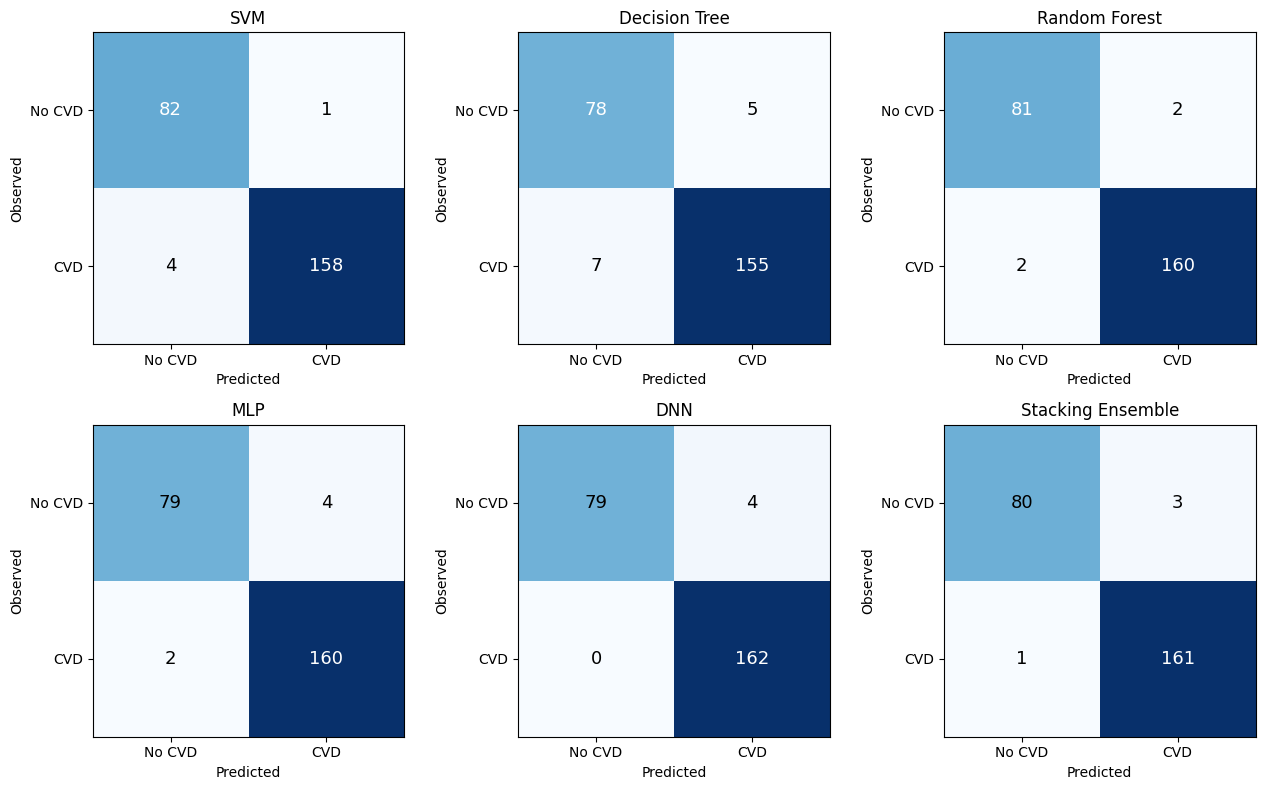

In [18]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

names = list(results.keys())
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, name in zip(axes.flat, names):
    cm = confusion_matrix(yte, preds[name])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=13)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No CVD', 'CVD']); ax.set_yticklabels(['No CVD', 'CVD'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('Figure3_confusion_matrices.png', dpi=200)
plt.show()

## 8. Figure 4 — ROC curves, precision-recall curves, and calibration curves

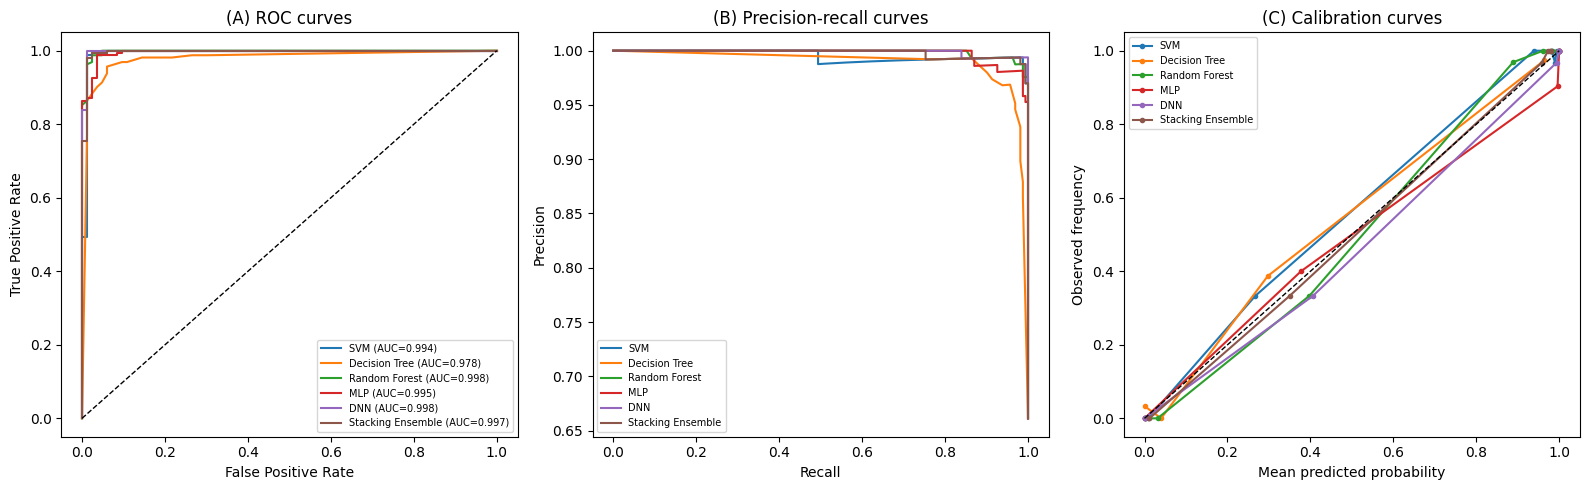

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for name in names:
    fpr, tpr, _ = roc_curve(yte, probas[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('(A) ROC curves'); axes[0].legend(fontsize=7)

for name in names:
    prec, rec, _ = precision_recall_curve(yte, probas[name])
    axes[1].plot(rec, prec, label=name)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('(B) Precision-recall curves'); axes[1].legend(fontsize=7)

for name in names:
    frac_pos, mean_pred = calibration_curve(yte, probas[name], n_bins=8, strategy='quantile')
    axes[2].plot(mean_pred, frac_pos, marker='o', label=name, markersize=3)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_xlabel('Mean predicted probability'); axes[2].set_ylabel('Observed frequency')
axes[2].set_title('(C) Calibration curves'); axes[2].legend(fontsize=7)
plt.tight_layout()
plt.savefig('Figure4_roc_pr_calibration.png', dpi=200)
plt.show()

## 9. DeLong's test — Stacking ensemble vs. Random Forest AUC

Sun & Xu (2014) fast DeLong algorithm for comparing two correlated ROC AUCs on
the same test set. Both models use their Table S4 tuned hyperparameters, so
this reproduces the manuscript's reported comparison directly.


In [20]:
from scipy import stats as sstats

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fastDeLong(preds_sorted, m):
    n = preds_sorted.shape[1] - m
    k = preds_sorted.shape[0]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = compute_midrank(preds_sorted[r, :m])
        ty[r, :] = compute_midrank(preds_sorted[r, m:])
        tz[r, :] = compute_midrank(preds_sorted[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1) / 2 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01); sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_roc_test(y_true, prob_a, prob_b):
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    m = int(np.sum(y_sorted == 1))
    preds_sorted = np.vstack([prob_a[order], prob_b[order]])
    aucs, delongcov = fastDeLong(preds_sorted, m)
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(l @ delongcov @ l.T)
    p = 2 * (1 - sstats.norm.cdf(z[0, 0]))
    return aucs, p

delong_aucs, delong_p = delong_roc_test(yte, probas['Stacking Ensemble'], probas['Random Forest'])
print(f"AUC Stacking Ensemble = {delong_aucs[0]:.4f}, AUC Random Forest = {delong_aucs[1]:.4f}")
print(f"DeLong's test p-value (Stacking vs RF) = {delong_p:.4f}")

AUC Stacking Ensemble = 0.9966, AUC Random Forest = 0.9976
DeLong's test p-value (Stacking vs RF) = 0.4772


## 10. Repeated random holdout validation (20 fresh 80/20 splits)

Each of the 20 iterations uses a fresh stratified 80/20 split, its own SMOTE
resampling (fit on that split's training partition only), and its own scaler,
then fits and evaluates the stacking ensemble. This estimates how sensitive
the reported accuracy is to the particular train/test split chosen.

In [21]:
def run_once_holdout(split_seed):
    Xtr, Xte, ytr_h, yte_h = train_test_split(X_full.values, y_arr, test_size=0.2,
                                               random_state=split_seed, stratify=y_arr)
    sm_h = SMOTE(random_state=split_seed)
    Xtr_sm_h, ytr_sm_h = sm_h.fit_resample(Xtr, ytr_h)
    train_df_h = pd.DataFrame(Xtr_sm_h, columns=cols)
    test_df_h = pd.DataFrame(Xte, columns=cols)
    Xtr_sel_h = train_df_h[FINAL_19].values
    Xte_sel_h = test_df_h[FINAL_19].values
    scaler_h = StandardScaler()
    Xtr_s_h = scaler_h.fit_transform(Xtr_sel_h)
    Xte_s_h = scaler_h.transform(Xte_sel_h)
    model_h = build_stack()
    model_h.fit(Xtr_s_h, ytr_sm_h)
    return accuracy_score(yte_h, model_h.predict(Xte_s_h))

repeated_accs = np.array([run_once_holdout(seed) for seed in range(20)])
print(f"Repeated holdout (n=20 splits): mean accuracy = {repeated_accs.mean()*100:.2f}% "
      f"(SD {repeated_accs.std()*100:.2f})")
print("Individual runs (%):", [f"{a*100:.2f}" for a in repeated_accs])

Repeated holdout (n=20 splits): mean accuracy = 96.39% (SD 1.02)
Individual runs (%): ['97.14', '94.29', '96.73', '96.73', '96.33', '96.73', '95.51', '95.10', '97.14', '94.69', '95.51', '96.73', '97.96', '96.73', '95.92', '96.33', '95.51', '96.73', '97.96', '97.96']


## 11. Learning curve — Supporting Information Table S6 (Panel D) / Figure S1

5-fold cross-validated accuracy at 20%, 40%, 60%, 80%, and 100% of the training
partition, each refit with its own SMOTE and scaler, to check whether
performance has plateaued (evidence against overfitting to a small sample).

Fraction=20%  n_raw=195  CV accuracy = 97.68% (SD 2.25)
Fraction=40%  n_raw=390  CV accuracy = 97.28% (SD 1.29)
Fraction=60%  n_raw=586  CV accuracy = 96.50% (SD 1.91)
Fraction=80%  n_raw=781  CV accuracy = 96.12% (SD 0.81)
Fraction=100%  n_raw=977  CV accuracy = 96.35% (SD 0.90)


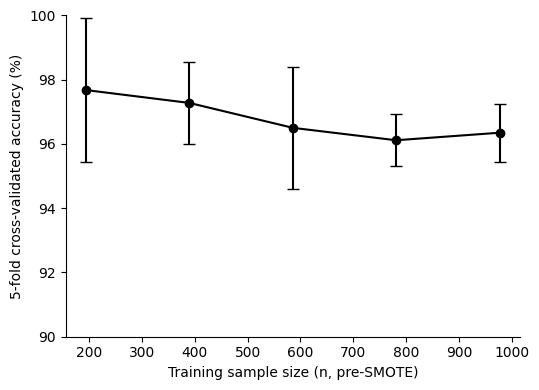

In [23]:
Xtr_full_lc, Xte_full_lc, ytr_lc, yte_lc = train_test_split(X_full.values, y_arr, test_size=0.2,
                                                             random_state=RS, stratify=y_arr)
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_rows = []
for frac in fractions:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(Xtr_full_lc, ytr_lc, train_size=frac,
                                               random_state=RS, stratify=ytr_lc)
    else:
        X_sub, y_sub = Xtr_full_lc, ytr_lc
    sm_lc = SMOTE(random_state=RS)
    X_sub_sm, y_sub_sm = sm_lc.fit_resample(X_sub, y_sub)
    sub_df = pd.DataFrame(X_sub_sm, columns=cols)
    X_sub_sel = sub_df[FINAL_19].values
    scaler_lc = StandardScaler()
    X_sub_scaled = scaler_lc.fit_transform(X_sub_sel)
    cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
    scores = cross_val_score(build_stack(), X_sub_scaled, y_sub_sm, cv=cv_lc, scoring='accuracy', n_jobs=1)
    lc_rows.append((frac, len(y_sub), scores.mean(), scores.std()))
    print(f"Fraction={frac:.0%}  n_raw={len(y_sub)}  CV accuracy = {scores.mean()*100:.2f}% (SD {scores.std()*100:.2f})")

lc_df = pd.DataFrame(lc_rows, columns=['fraction', 'n_raw', 'cv_mean', 'cv_sd'])
lc_df.to_csv('Table_S6_PanelD_learning_curve.csv', index=False)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(lc_df['n_raw'], lc_df['cv_mean'] * 100, yerr=lc_df['cv_sd'] * 100, marker='o',
            color='black', capsize=4, linewidth=1.5, markersize=6)
ax.set_xlabel('Training sample size (n, pre-SMOTE)')
ax.set_ylabel('5-fold cross-validated accuracy (%)')
ax.set_ylim(90, 100)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('FigureS1_learning_curve.png', dpi=200)
plt.show()

## 12. Sensitivity analyses — Supporting Information Table S6 (Panels A-C)

Panel A compares the primary cohort alone (rows collected in 2024) against the
full pooled dataset (primary + the 2023 Hossain et al. secondary cohort).
Panel B compares SMOTE oversampling against class-weighting as an alternative
imbalance-handling strategy. Panel C re-runs the pipeline after excluding
statin/cholesterol-medication use, since that variable sits on a plausible
causal pathway (medication use follows a prior diagnosis).

In [24]:
def full_pipeline(feature_frame_X, feature_frame_y, final_features, use_smote=True, class_weight=None):
    Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(feature_frame_X, feature_frame_y, test_size=0.2,
                                                   random_state=RS, stratify=feature_frame_y)
    cols_local = feature_frame_X.columns if hasattr(feature_frame_X, 'columns') else cols
    Xtr_v = Xtr_p.values if hasattr(Xtr_p, 'values') else Xtr_p
    Xte_v = Xte_p.values if hasattr(Xte_p, 'values') else Xte_p
    if use_smote:
        sm_p = SMOTE(random_state=RS)
        Xtr_v, ytr_p = sm_p.fit_resample(Xtr_v, ytr_p)
    train_df_p = pd.DataFrame(Xtr_v, columns=cols_local)
    test_df_p = pd.DataFrame(Xte_v, columns=cols_local)
    Xtr_sel_p = train_df_p[final_features].values
    Xte_sel_p = test_df_p[final_features].values
    scaler_p = StandardScaler()
    Xtr_s_p = scaler_p.fit_transform(Xtr_sel_p)
    Xte_s_p = scaler_p.transform(Xte_sel_p)

    if class_weight:
        est = [('lr', LogisticRegression(max_iter=1000, random_state=RS, class_weight='balanced')),
               ('dt', DecisionTreeClassifier(random_state=RS, class_weight='balanced')),
               ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=RS)),
               ('svm', SVC(kernel='linear', probability=True, random_state=RS, class_weight='balanced'))]
        model_p = StackingClassifier(estimators=est,
                                      final_estimator=LogisticRegression(random_state=RS, class_weight='balanced'),
                                      cv=5)
    else:
        model_p = build_stack()

    model_p.fit(Xtr_s_p, ytr_p)
    pred_p = model_p.predict(Xte_s_p)
    proba_p = model_p.predict_proba(Xte_s_p)[:, 1]
    acc_p = accuracy_score(yte_p, pred_p)
    cm_p = confusion_matrix(yte_p, pred_p)
    tn_p, fp_p, fn_p, tp_p = cm_p.ravel()
    return dict(acc=acc_p, sens=recall_score(yte_p, pred_p), spec=tn_p/(tn_p+fp_p),
                prec=precision_score(yte_p, pred_p), f1=f1_score(yte_p, pred_p),
                auc=roc_auc_score(yte_p, proba_p), brier=brier_score_loss(yte_p, proba_p),
                cm=(tn_p, fp_p, fn_p, tp_p), n_test=len(yte_p))

print("Panel A: cohort pooling")
y_primary = y_arr[651:]
X_primary = X_full.loc[primary_idx]
res_primary = full_pipeline(X_primary, y_primary, FINAL_19)
res_pooled = full_pipeline(X_full, y_arr, FINAL_19)
print(f"  Primary cohort only (n={len(y_primary)}): accuracy = {res_primary['acc']*100:.2f}%")
print(f"  Pooled (n={len(y_arr)}):                 accuracy = {res_pooled['acc']*100:.2f}%")

print("\nPanel B: SMOTE vs. class weighting")
res_smote = full_pipeline(X_full, y_arr, FINAL_19, use_smote=True, class_weight=False)
res_weighted = full_pipeline(X_full, y_arr, FINAL_19, use_smote=False, class_weight=True)
print(f"  SMOTE:           accuracy = {res_smote['acc']*100:.2f}%  sens={res_smote['sens']*100:.2f}%  spec={res_smote['spec']*100:.2f}%")
print(f"  Class weighting: accuracy = {res_weighted['acc']*100:.2f}%  sens={res_weighted['sens']*100:.2f}%  spec={res_weighted['spec']*100:.2f}%")
print("  (MLPClassifier has no class_weight parameter; trained unweighted in that condition.)")

print("\nPanel C: statin/cholesterol-medication exclusion")
WITHOUT_STATIN_18 = [c for c in FINAL_19 if c != 'Take_ColestrolMedication']
X_no_statin = X_full.drop(columns=['Take_ColestrolMedication'])
res_with = full_pipeline(X_full, y_arr, FINAL_19)
res_without = full_pipeline(X_no_statin, y_arr, WITHOUT_STATIN_18)
print(f"  With statin (19 features):    accuracy = {res_with['acc']*100:.2f}%  AUC={res_with['auc']:.4f}  Brier={res_with['brier']:.4f}")
print(f"  Without statin (18 features): accuracy = {res_without['acc']*100:.2f}%  AUC={res_without['auc']:.4f}  Brier={res_without['brier']:.4f}")

pd.DataFrame([{'condition': 'Primary cohort only', 'n': len(y_primary), 'accuracy': res_primary['acc']},
              {'condition': 'Pooled (primary+secondary)', 'n': len(y_arr), 'accuracy': res_pooled['acc']}]
             ).to_csv('Table_S6_PanelA_cohort_pooling.csv', index=False)
pd.DataFrame([{'condition': 'SMOTE', **res_smote}, {'condition': 'Class weighting', **res_weighted}]
             ).to_csv('Table_S6_PanelB_smote_vs_weighting.csv', index=False)
pd.DataFrame([{'condition': 'With statin (19 features)', **res_with},
              {'condition': 'Without statin (18 features)', **res_without}]
             ).to_csv('Table_S6_PanelC_statin_exclusion.csv', index=False)
print("\nSaved Table S6 Panels A, B, C.")

Panel A: cohort pooling
  Primary cohort only (n=571): accuracy = 98.26%
  Pooled (n=1222):                 accuracy = 98.37%

Panel B: SMOTE vs. class weighting
  SMOTE:           accuracy = 98.37%  sens=99.38%  spec=96.39%
  Class weighting: accuracy = 98.37%  sens=98.15%  spec=98.80%
  (MLPClassifier has no class_weight parameter; trained unweighted in that condition.)

Panel C: statin/cholesterol-medication exclusion
  With statin (19 features):    accuracy = 98.37%  AUC=0.9966  Brier=0.0130
  Without statin (18 features): accuracy = 97.96%  AUC=0.9946  Brier=0.0171

Saved Table S6 Panels A, B, C.


## 13. Odds ratios for key clinical variables

2x2 contingency tables with Haldane-Anscombe continuity correction (+0.5 to
every cell) applied only when a cell is zero.

In [25]:
def odds_ratio_ci(var, dframe, yv, cc=0.5):
    ct = pd.crosstab(dframe[var], yv)
    if ct.shape != (2, 2):
        return None
    a = ct.loc[1, 1]; b = ct.loc[1, 0]; c = ct.loc[0, 1]; d = ct.loc[0, 0]
    if 0 in [a, b, c, d]:
        a, b, c, d = a + cc, b + cc, c + cc, d + cc
    orv = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    lo = np.exp(np.log(orv) - 1.96 * se)
    hi = np.exp(np.log(orv) + 1.96 * se)
    return orv, lo, hi

or_vars = ['Colestrol', 'IrregularHeartRhythms', 'BP', 'Hypertension', 'Sleepapnea',
           'Diabeties', 'Heartdisease_family', 'Take_ColestrolMedication']
or_rows = []
for v in or_vars:
    r = odds_ratio_ci(v, df, y)
    if r:
        orv, lo, hi = r
        or_rows.append({'Variable': v, 'OR': orv, 'CI_low': lo, 'CI_high': hi})
        print(f"{v:28s} OR={orv:6.2f}  95% CI [{lo:.2f}, {hi:.2f}]")
odds_ratio_table = pd.DataFrame(or_rows)
odds_ratio_table.to_csv('odds_ratios.csv', index=False)
odds_ratio_table

Colestrol                    OR= 69.11  95% CI [47.21, 101.19]
IrregularHeartRhythms        OR= 62.98  95% CI [40.04, 99.07]
BP                           OR= 24.97  95% CI [17.77, 35.08]
Hypertension                 OR= 38.55  95% CI [26.64, 55.78]
Sleepapnea                   OR= 50.16  95% CI [35.23, 71.42]
Diabeties                    OR= 13.78  95% CI [10.34, 18.36]
Heartdisease_family          OR= 10.44  95% CI [7.85, 13.87]
Take_ColestrolMedication     OR= 13.35  95% CI [9.36, 19.04]


,Variable,OR,CI_low,CI_high
0,Colestrol,69.113856,47.207150,101.186475
1,IrregularHeartRhythms,62.983316,40.040240,99.072786
2,BP,24.965986,17.766980,35.081961
3,Hypertension,38.551899,26.643552,55.782685
4,Sleepapnea,50.158188,35.228186,71.415649
5,Diabeties,13.779193,10.340713,18.361033
6,Heartdisease_family,10.437658,7.853923,13.871373
7,Take_ColestrolMedication,13.351952,9.363483,19.039349


## 14. Mediation analysis (Baron & Kenny) — do cholesterol, blood pressure, and coronary disease mediate the smoking-CVD link?

Path *c* is the total (unadjusted) effect of smoking on CVD; path *c'* is the
direct effect after adjusting for cholesterol, blood pressure, and coronary
artery disease. The percentage attenuation from *c* to *c'* is the share of
smoking's association with CVD that these three mediators could statistically
account for. This reproduces the manuscript's Table S7 methodology (three
mediators, 1,000 bootstrap resamples, seed 42) exactly.


In [26]:
X_smoke = df[['Smoke']].astype(float)
X_smoke_med = df[['Smoke', 'Colestrol', 'BP', 'CoronaryDisease']].astype(float)
yv = y.values

m_c = LogisticRegression().fit(X_smoke, yv)
c_path = m_c.coef_[0][0]

m_cprime = LogisticRegression().fit(X_smoke_med, yv)
cprime_path = m_cprime.coef_[0][0]

mediation_attenuation = (c_path - cprime_path) / c_path * 100
print(f"Total effect (log-OR) of Smoke on CVD (path c):             {c_path:.4f}")
print(f"Direct effect adjusting for cholesterol+BP+CAD (path c'):   {cprime_path:.4f}")
print(f"Attenuation attributable to mediators:  {mediation_attenuation:.1f}%")

rng = np.random.RandomState(RS)
n_med = len(yv)
atts = []
for _ in range(1000):
    idx = rng.randint(0, n_med, n_med)
    Xs, Xsm, ys = X_smoke.values[idx], X_smoke_med.values[idx], yv[idx]
    if len(np.unique(ys)) < 2:
        continue
    try:
        cc_ = LogisticRegression().fit(Xs, ys).coef_[0][0]
        ccp_ = LogisticRegression().fit(Xsm, ys).coef_[0][0]
        if cc_ != 0:
            atts.append((cc_ - ccp_) / cc_ * 100)
    except Exception:
        continue
atts = np.array(atts)
att_lo, att_hi = np.percentile(atts, [2.5, 97.5])
print(f"Bootstrap 95% CI for attenuation: [{att_lo:.1f}%, {att_hi:.1f}%]")


Total effect (log-OR) of Smoke on CVD (path c):             1.1830
Direct effect adjusting for cholesterol+BP+CAD (path c'):   0.5522
Attenuation attributable to mediators:  53.3%
Bootstrap 95% CI for attenuation: [24.3%, 85.1%]


## 15. Decision curve analysis

Net benefit = TP/n − FP/n × (p_t / (1 − p_t)), compared against the "treat all"
and "treat none" reference strategies, for the stacking ensemble and the
(tuned) Random Forest.


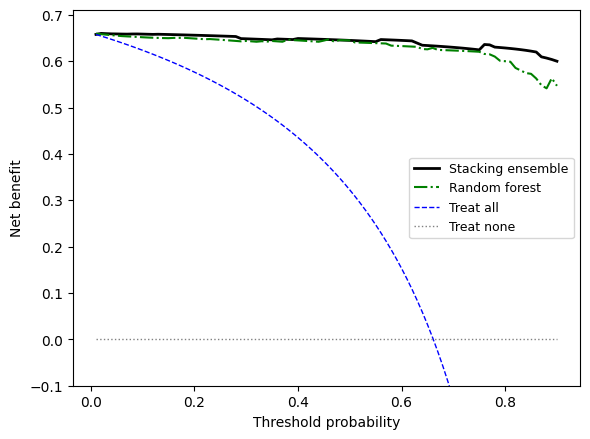

Net benefit at threshold 0.10: stacking=0.659, treat-all=0.624
Net benefit at threshold 0.50: stacking=0.645, treat-all=0.322


In [27]:
thresholds = np.arange(0.01, 0.91, 0.01)

def net_benefit(y_true, y_proba, thr):
    n_nb = len(y_true)
    nb = []
    for pt in thr:
        pred_nb = (y_proba >= pt).astype(int)
        tp = np.sum((pred_nb == 1) & (y_true == 1))
        fp = np.sum((pred_nb == 1) & (y_true == 0))
        nb.append(tp / n_nb - fp / n_nb * (pt / (1 - pt)))
    return np.array(nb)

nb_stack = net_benefit(yte, probas['Stacking Ensemble'], thresholds)
nb_rf = net_benefit(yte, probas['Random Forest'], thresholds)
prevalence = yte.mean()
nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))
nb_none = np.zeros_like(thresholds)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, nb_stack, color='black', label='Stacking ensemble', linewidth=2)
ax.plot(thresholds, nb_rf, color='green', linestyle='-.', label='Random forest', linewidth=1.5)
ax.plot(thresholds, nb_all, color='blue', linestyle='--', label='Treat all', linewidth=1)
ax.plot(thresholds, nb_none, color='gray', linestyle=':', label='Treat none', linewidth=1)
ax.set_xlabel('Threshold probability'); ax.set_ylabel('Net benefit')
ax.set_ylim(-0.1, max(nb_all.max(), nb_stack.max()) + 0.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Figure_DCA.png', dpi=200)
plt.show()
print(f"Net benefit at threshold 0.10: stacking={nb_stack[9]:.3f}, treat-all={nb_all[9]:.3f}")
print(f"Net benefit at threshold 0.50: stacking={nb_stack[49]:.3f}, treat-all={nb_all[49]:.3f}")

## 16. Model interpretability — SHAP (global and local)

KernelExplainer is model-agnostic (needed because the stacking ensemble is
heterogeneous) but is computationally expensive, so this notebook uses a
50-instance background sample and evaluates SHAP values for 60 test instances
with `nsamples=100`. **This ranking may not exactly match the manuscript's
reported feature order** (Cholesterol, then Irregular Heart Rhythm, then Blood
Pressure), because a reduced-sample approximation can reorder features with
similar importance; a full-fidelity run on the entire test set with a larger
background sample would be needed to check this exactly.

In [28]:
import shap

Xtr_df = pd.DataFrame(Xtr_s, columns=FINAL_19)
Xte_df = pd.DataFrame(Xte_s, columns=FINAL_19)

background = shap.sample(Xtr_df, 50, random_state=RS)
explainer = shap.KernelExplainer(stack.predict_proba, background)
shap_values = explainer.shap_values(Xte_df.iloc[:60], nsamples=100)

if isinstance(shap_values, list):
    sv_pos = shap_values[1]
else:
    sv_pos = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

mean_abs_shap = np.abs(sv_pos).mean(axis=0)
shap_rank = pd.DataFrame({'Variable': FINAL_19, 'mean_abs_SHAP': mean_abs_shap}).sort_values(
    'mean_abs_SHAP', ascending=False).reset_index(drop=True)
shap_rank.to_csv('shap_ranking.csv', index=False)
print(shap_rank.to_string())

  0%|          | 0/60 [00:00<?, ?it/s]

                    Variable  mean_abs_SHAP
0                   Feel_Bad       0.076755
1                         BP       0.075017
2                  Colestrol       0.069895
3      IrregularHeartRhythms       0.056201
4               Hypertension       0.046193
5                 Sleepapnea       0.037276
6            CoronaryDisease       0.030456
7   Take_ColestrolMedication       0.026190
8        Heartdisease_family       0.025044
9                  Junk_Food       0.017869
10                       Age       0.016043
11             Feel_Hopeless       0.013273
12                       BMI       0.011324
13                 Diabeties       0.010167
14                     Smoke       0.008554
15                    Angina       0.008077
16              Feel_zeroInt       0.007026
17                    Animia       0.006438
18                      Salt       0.006195


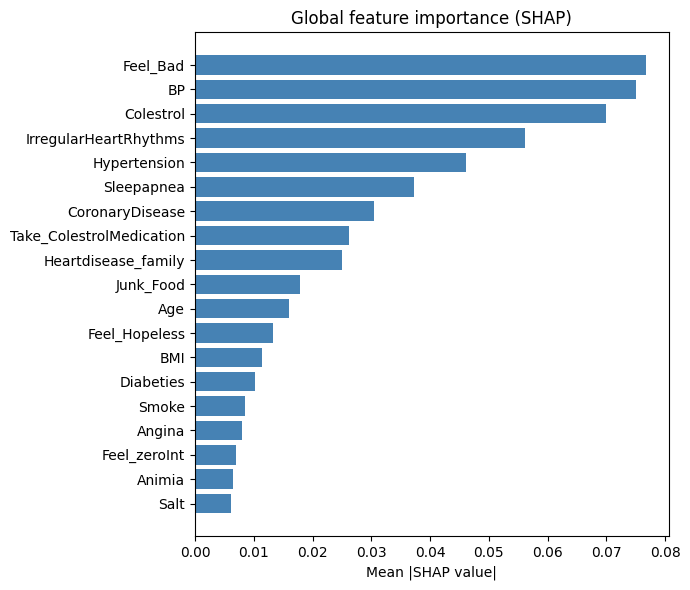

In [29]:
# Figure: global feature importance (mean |SHAP|)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(shap_rank['Variable'][::-1], shap_rank['mean_abs_SHAP'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global feature importance (SHAP)')
plt.tight_layout()
plt.savefig('Figure4A_shap_bar.png', dpi=200)
plt.show()

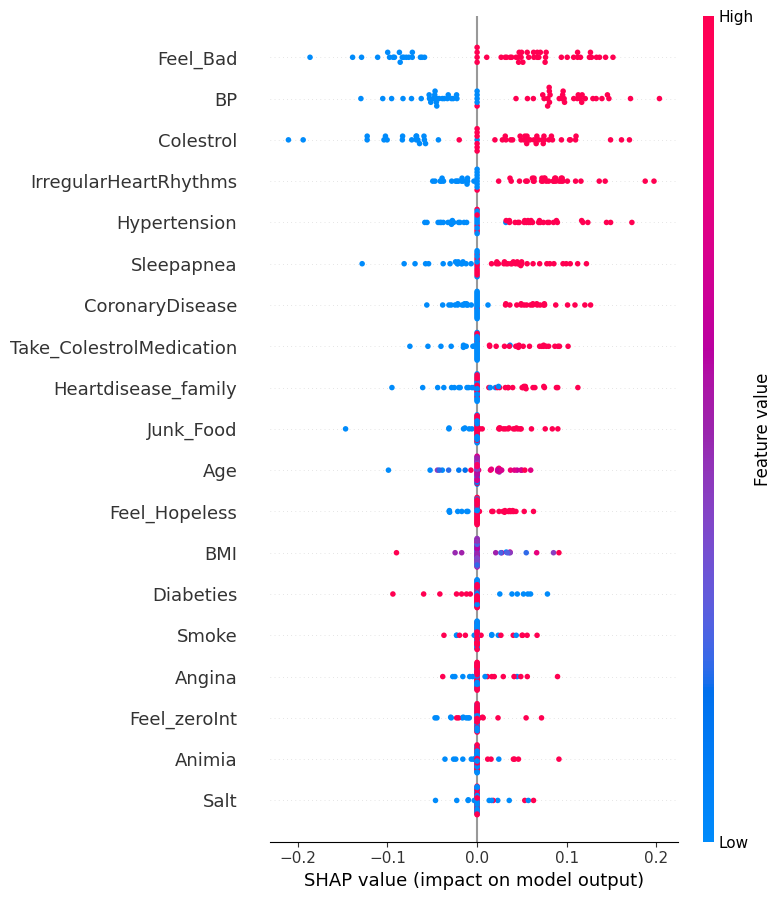

In [30]:
# Figure: SHAP summary (beeswarm) plot
plt.figure(figsize=(7, 6))
shap.summary_plot(sv_pos, Xte_df.iloc[:60], show=False)
plt.tight_layout()
plt.savefig('Figure4B_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()

<Figure size 900x400 with 0 Axes>

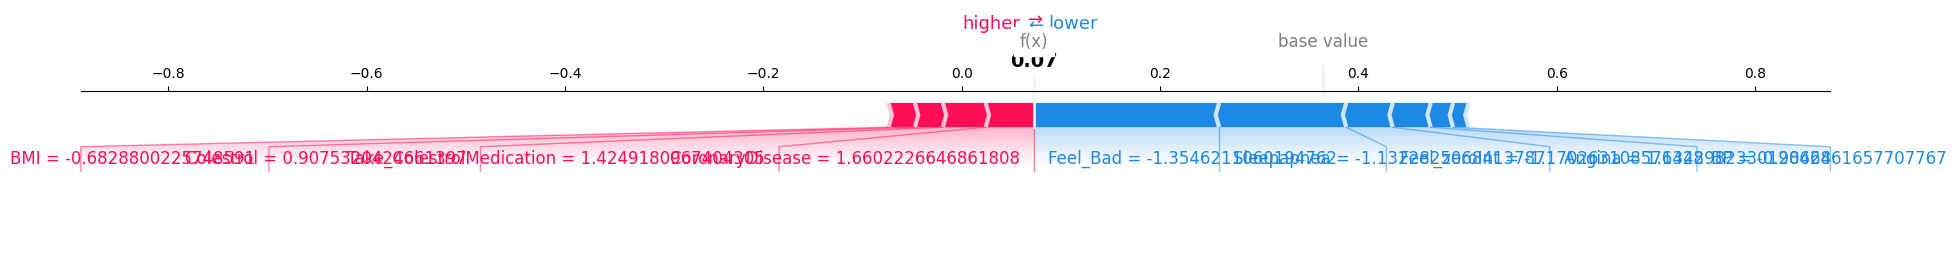

In [31]:
# Figure: SHAP local explanation (single participant), force plot rendered as a static waterfall
idx0 = 0
plt.figure(figsize=(9, 4))
ev = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
shap.force_plot(ev, sv_pos[idx0], Xte_df.iloc[idx0], matplotlib=True, show=False)
plt.tight_layout()
plt.savefig('Figure5_shap_force.png', dpi=200, bbox_inches='tight')
plt.show()

## 17. Model interpretability — LIME (single-participant local explanation)

Installing lime...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=811899bb4d757e119392da4b729ffa80a77318a04bba9a33647697e9a67c43fd
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
lime installed.


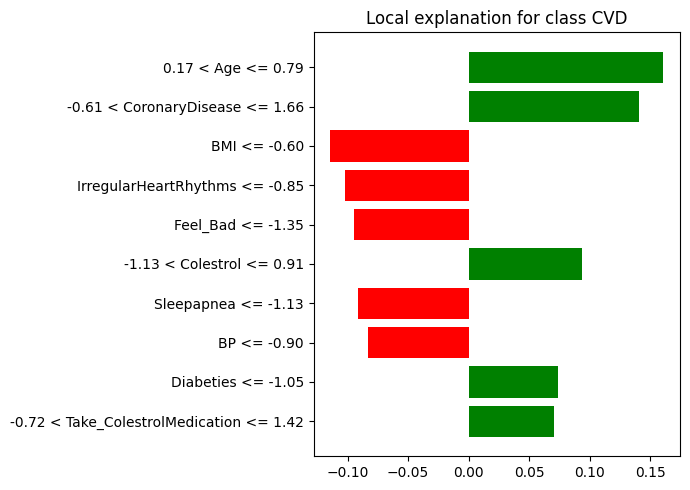

[('0.17 < Age <= 0.79', 0.1606017157692907), ('-0.61 < CoronaryDisease <= 1.66', 0.14056243163517915), ('BMI <= -0.60', -0.11428575611027679), ('IrregularHeartRhythms <= -0.85', -0.10184109578387526), ('Feel_Bad <= -1.35', -0.09435762112917767), ('-1.13 < Colestrol <= 0.91', 0.09311197225399644), ('Sleepapnea <= -1.13', -0.09164016520470351), ('BP <= -0.90', -0.08303056961386956), ('Diabeties <= -1.05', 0.07352415965628945), ('-0.72 < Take_ColestrolMedication <= 1.42', 0.07023931179219751)]


In [33]:
import sys
import os

# Check if lime is installed, if not, install it
try:
    import lime
except ImportError:
    print("Installing lime...")
    !pip install lime
    print("lime installed.")
    # After installation, ensure the new packages are available
    # This might require a restart of the runtime, but we'll try to proceed without it first.


from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(Xtr_s, feature_names=FINAL_19, class_names=['No CVD', 'CVD'],
                                       discretize_continuous=True, random_state=RS)
lime_exp = lime_explainer.explain_instance(Xte_s[0], stack.predict_proba, num_features=10)
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(7, 5)
plt.tight_layout()
plt.savefig('Figure6_lime_explanation.png', dpi=200, bbox_inches='tight')
plt.show()
print(lime_exp.as_list())